# Ride Demand Forecasting Pipeline
Refined notebook for transforming raw pickup records into an hourly demand forecasting workflow.

## 1. Imports and paths

In [1]:

from pathlib import Path
import json
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

pd.set_option('display.max_columns', 100)

project_dir = Path.cwd().resolve().parent
data_path = project_dir / "data" / "uber_raw_apr14.csv"
output_dir = project_dir / "outputs"
output_dir.mkdir(exist_ok=True)


## 2. Load the raw ride data

In [2]:

rides = pd.read_csv(data_path)
rides.columns = (
    rides.columns
    .str.strip()
    .str.lower()
    .str.replace("/", "_")
)
print("Rows, columns:", rides.shape)
rides.head()


Rows, columns: (564516, 4)


,date_time,lat,lon,base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


## 3. Parse datetimes and engineer time features

In [3]:

rides["date_time"] = pd.to_datetime(rides["date_time"], errors="coerce")
rides = rides.dropna(subset=["date_time"]).copy()

rides["date"] = rides["date_time"].dt.date.astype(str)
rides["hour"] = rides["date_time"].dt.hour
rides["day"] = rides["date_time"].dt.day
rides["weekday_num"] = rides["date_time"].dt.weekday
rides["weekday"] = rides["date_time"].dt.day_name()
rides["is_weekend"] = rides["weekday_num"].isin([5, 6]).astype(int)

rides["lat"] = pd.to_numeric(rides["lat"], errors="coerce")
rides["lon"] = pd.to_numeric(rides["lon"], errors="coerce")
rides["base"] = rides["base"].astype(str)

rides[["date_time", "base", "hour", "day", "weekday", "is_weekend"]].head()


,date_time,base,hour,day,weekday,is_weekend
0,2014-04-01 00:11:00,B02512,0,1,Tuesday,0
1,2014-04-01 00:17:00,B02512,0,1,Tuesday,0
2,2014-04-01 00:21:00,B02512,0,1,Tuesday,0
3,2014-04-01 00:28:00,B02512,0,1,Tuesday,0
4,2014-04-01 00:33:00,B02512,0,1,Tuesday,0


## 4. Aggregate to hourly demand

In [4]:

hourly_demand = (
    rides.groupby(["date", "day", "hour", "weekday", "weekday_num", "is_weekend"], as_index=False)
    .agg(
        pickups=("base", "size"),
        avg_lat=("lat", "mean"),
        avg_lon=("lon", "mean"),
        active_bases=("base", "nunique"),
    )
    .sort_values(["date", "hour"])
    .reset_index(drop=True)
)
hourly_demand["record_id"] = np.arange(len(hourly_demand))
hourly_demand.head()


,date,day,hour,weekday,weekday_num,is_weekend,pickups,avg_lat,avg_lon,active_bases,record_id
0,2014-04-01,1,0,Tuesday,1,0,138,40.735587,-73.973854,5,0
1,2014-04-01,1,1,Tuesday,1,0,66,40.738630,-73.982238,5,1
2,2014-04-01,1,2,Tuesday,1,0,53,40.745704,-73.972279,5,2
3,2014-04-01,1,3,Tuesday,1,0,93,40.742248,-73.974381,5,3
4,2014-04-01,1,4,Tuesday,1,0,166,40.725503,-73.963337,5,4


## 5. Add lag and rolling features

In [5]:

hourly_demand["lag_1"] = hourly_demand["pickups"].shift(1)
hourly_demand["lag_24"] = hourly_demand["pickups"].shift(24)
hourly_demand["rolling_mean_3"] = hourly_demand["pickups"].shift(1).rolling(3).mean()
hourly_demand["rolling_mean_24"] = hourly_demand["pickups"].shift(1).rolling(24).mean()
hourly_demand["hour_sin"] = np.sin(2 * np.pi * hourly_demand["hour"] / 24)
hourly_demand["hour_cos"] = np.cos(2 * np.pi * hourly_demand["hour"] / 24)

model_df = hourly_demand.dropna().copy()
model_df.head()


,date,day,hour,weekday,weekday_num,is_weekend,pickups,avg_lat,avg_lon,active_bases,record_id,lag_1,lag_24,rolling_mean_3,rolling_mean_24,hour_sin,hour_cos
24,2014-04-02,2,0,Wednesday,2,0,161,40.730884,-73.974148,5,24,317.0,138.0,574.666667,606.083333,0.000000,1.000000
25,2014-04-02,2,1,Wednesday,2,0,82,40.734415,-73.983902,5,25,161.0,66.0,335.666667,607.041667,0.258819,0.965926
26,2014-04-02,2,2,Wednesday,2,0,59,40.748854,-73.971176,5,26,82.0,53.0,186.666667,607.708333,0.500000,0.866025
27,2014-04-02,2,3,Wednesday,2,0,80,40.734828,-73.969981,5,27,59.0,93.0,100.666667,607.958333,0.707107,0.707107
28,2014-04-02,2,4,Wednesday,2,0,196,40.730737,-73.972366,5,28,80.0,166.0,73.666667,607.416667,0.866025,0.500000


## 6. Export core tables for GitHub and SQL talking points

In [6]:

hourly_demand.to_csv(output_dir / "hourly_demand.csv", index=False)

base_summary = (
    rides.groupby("base", as_index=False)
    .agg(
        total_pickups=("base", "size"),
        avg_lat=("lat", "mean"),
        avg_lon=("lon", "mean"),
    )
    .sort_values("total_pickups", ascending=False)
)
base_summary.to_csv(output_dir / "base_summary.csv", index=False)

zone_hourly_demand = (
    rides.groupby(["base", "hour"], as_index=False)
    .agg(pickups=("base", "size"))
    .sort_values(["base", "hour"])
)
zone_hourly_demand.to_csv(output_dir / "zone_hourly_demand.csv", index=False)

peak_hours = (
    hourly_demand.groupby("hour", as_index=False)
    .agg(avg_pickups=("pickups", "mean"))
    .sort_values("avg_pickups", ascending=False)
)
peak_hours.to_csv(output_dir / "peak_hours.csv", index=False)

base_summary.head()


,base,total_pickups,avg_lat,avg_lon
3,B02682,227808,40.740105,-73.976525
1,B02598,183263,40.739812,-73.976342
2,B02617,108001,40.738384,-73.976526
0,B02512,35536,40.745493,-73.981345
4,B02764,9908,40.739266,-73.979240


## 7. Visualise demand patterns

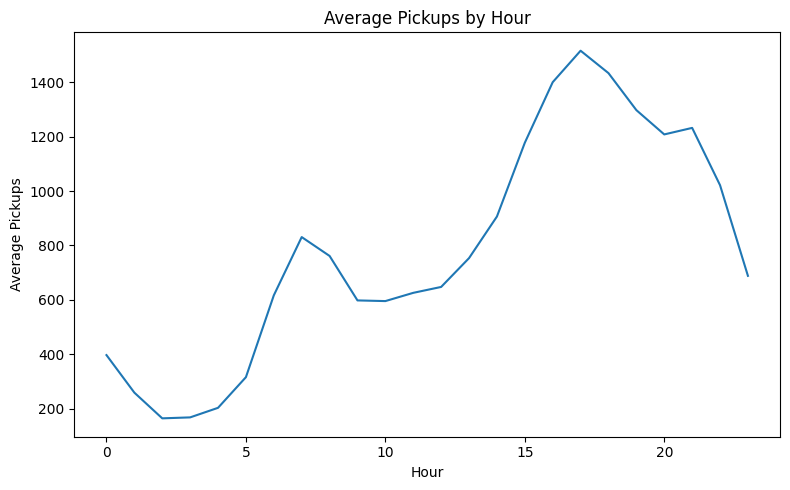

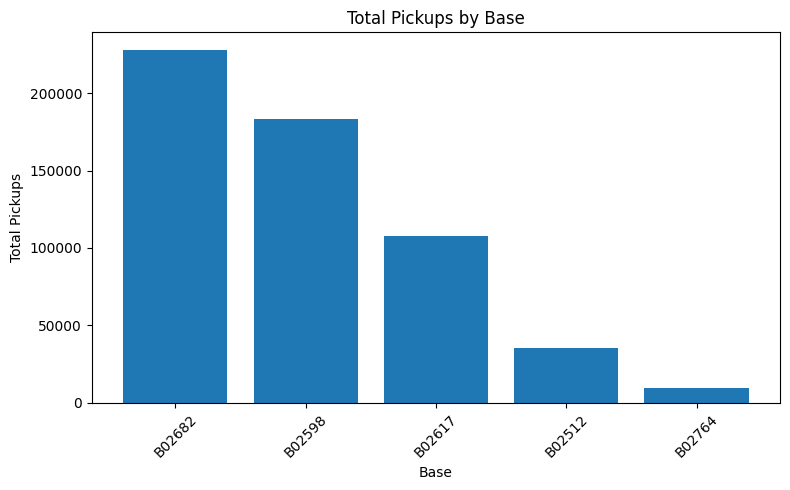

In [7]:

avg_hour = (
    hourly_demand.groupby("hour", as_index=False)
    .agg(avg_pickups=("pickups", "mean"))
)

plt.figure(figsize=(8, 5))
plt.plot(avg_hour["hour"], avg_hour["avg_pickups"])
plt.title("Average Pickups by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Pickups")
plt.tight_layout()
plt.savefig(output_dir / "average_pickups_by_hour.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(base_summary["base"], base_summary["total_pickups"])
plt.title("Total Pickups by Base")
plt.xlabel("Base")
plt.ylabel("Total Pickups")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(output_dir / "total_pickups_by_base.png", dpi=150)
plt.show()


## 8. Train/test split

In [8]:

features = [
    "hour", "day", "weekday", "weekday_num", "is_weekend",
    "active_bases", "avg_lat", "avg_lon", "lag_1", "lag_24",
    "rolling_mean_3", "rolling_mean_24", "hour_sin", "hour_cos"
]
X = model_df[features]
y = model_df["pickups"]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (556, 14) Test shape: (140, 14)


## 9. Build and compare two models

In [9]:

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)

models = {
    "linear_regression": LinearRegression(),
    "random_forest": RandomForestRegressor(
        n_estimators=250,
        max_depth=14,
        min_samples_split=6,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
}

results = []
fitted_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    results.append({
        "model": name,
        "mae": mean_absolute_error(y_test, preds),
        "rmse": mean_squared_error(y_test, preds) ** 0.5,
        "r2": r2_score(y_test, preds),
    })
    fitted_models[name] = (pipeline, preds)

model_comparison = pd.DataFrame(results).sort_values("r2", ascending=False)
model_comparison.to_csv(output_dir / "model_comparison.csv", index=False)
model_comparison


,model,mae,rmse,r2
0,linear_regression,144.837929,200.631475,0.913918
1,random_forest,134.115936,218.594830,0.897814


## 10. Diagnostics for the best forecasting model

In [10]:

best_model_name = model_comparison.iloc[0]["model"]
best_pipeline, best_preds = fitted_models[best_model_name]

diagnostics = pd.DataFrame({
    "actual_pickups": y_test.reset_index(drop=True),
    "predicted_pickups": best_preds
})
diagnostics["residual"] = diagnostics["actual_pickups"] - diagnostics["predicted_pickups"]
diagnostics["abs_error"] = diagnostics["residual"].abs()
diagnostics.to_csv(output_dir / "prediction_diagnostics.csv", index=False)

diagnostics.head()


,actual_pickups,predicted_pickups,residual,abs_error
0,238,270.359259,-32.359259,32.359259
1,372,325.682904,46.317096,46.317096
2,796,566.276853,229.723147,229.723147
3,1054,1039.275516,14.724484,14.724484
4,937,1168.210577,-231.210577,231.210577


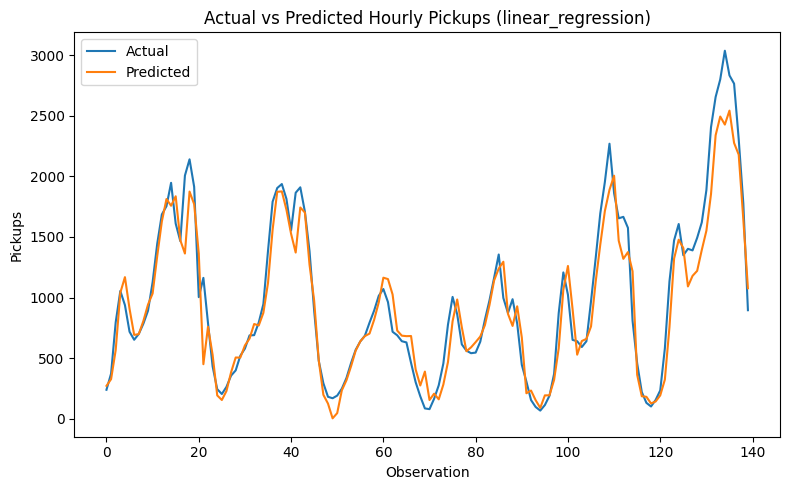

In [11]:

plt.figure(figsize=(8, 5))
plt.plot(diagnostics.index, diagnostics["actual_pickups"], label="Actual")
plt.plot(diagnostics.index, diagnostics["predicted_pickups"], label="Predicted")
plt.title(f"Actual vs Predicted Hourly Pickups ({best_model_name})")
plt.xlabel("Observation")
plt.ylabel("Pickups")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "actual_vs_predicted.png", dpi=150)
plt.show()


## 11. SQL-ready export

In [12]:

db_path = output_dir / "ride_demand.db"
conn = sqlite3.connect(db_path)
rides.to_sql("rides_raw", conn, if_exists="replace", index=False)
hourly_demand.to_sql("hourly_demand", conn, if_exists="replace", index=False)
conn.close()

print("SQLite database saved to:", db_path)


SQLite database saved to: /mnt/data/github-portfolio-refined-same-datasets/03_ride_demand_pipeline/outputs/ride_demand.db


## 12. Final summary

In [13]:

summary = {
    "best_model": best_model_name,
    "best_model_r2": round(float(model_comparison.iloc[0]["r2"]), 4),
    "top_base_by_pickups": base_summary.iloc[0]["base"],
    "busiest_hour": int(peak_hours.iloc[0]["hour"]),
    "avg_pickups_at_busiest_hour": round(float(peak_hours.iloc[0]["avg_pickups"]), 2),
}

with open(output_dir / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

summary


{'best_model': 'linear_regression',
 'best_model_r2': 0.9139,
 'top_base_by_pickups': 'B02682',
 'busiest_hour': 17,
 'avg_pickups_at_busiest_hour': 1515.83}

## 13. Recommendations
- Use peak-hour analysis for staffing and supply planning.
- Use base-level summaries to discuss operational concentration.
- Use the forecasting section to show you can move from raw event records to predictive features.